# Iteration 2: 60/20/20 Split + Backward Elimination

Goal: move beyond the seed-only baseline by using a deterministic three-way split, training-only feature selection, and a locked final test audit.

This version keeps the workflow disciplined:
- 60% training for fitting and CV-based backward elimination
- 20% validation for model/feature-set comparison
- 20% test for one final evaluation only
- recombine `train + validation` into a development set after the test audit


In [55]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 27
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
if sns is not None:
    sns.set_theme(style="whitegrid")


In [56]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Challenge-1").exists():
            return candidate
    raise FileNotFoundError("Could not find the IS-455 project root from the current notebook location.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHALLENGE_DIR = PROJECT_ROOT / "Challenge-1"
KAGGLE_DATA_DIR = CHALLENGE_DIR / "data-Kaggle"
BARTTORVIK_DATA_DIR = CHALLENGE_DIR / "data-BartTorvik"
ML_KIT_DIR = PROJECT_ROOT / "ML-Pipeline-Kit"

for path in [CHALLENGE_DIR, ML_KIT_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

import challenge_data_prep as prep
import ml_library as ml

print(f"Project root: {PROJECT_ROOT}")
print(f"Challenge directory: {CHALLENGE_DIR}")
print(f"Kaggle data directory: {KAGGLE_DATA_DIR}")
print(f"BartTorvik data directory: {BARTTORVIK_DATA_DIR}")


Project root: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455
Challenge directory: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455\Challenge-1
Kaggle data directory: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455\Challenge-1\data-Kaggle
BartTorvik data directory: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455\Challenge-1\data-BartTorvik


In [57]:
def choose_cv(y_train: pd.Series, groups_train: pd.Series | None = None):
    if groups_train is not None and pd.Series(groups_train).nunique(dropna=True) >= 3:
        n_splits = min(5, pd.Series(groups_train).nunique(dropna=True))
        return GroupKFold(n_splits=n_splits), f"GroupKFold({n_splits}) by year"

    min_class_count = int(pd.Series(y_train).value_counts().min())
    n_splits = min(5, min_class_count)
    if n_splits < 2:
        raise ValueError("Not enough observations per class for cross-validation.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE), f"StratifiedKFold({n_splits})"


def make_pipeline(feature_cols: list[str], estimator, scale_numeric: bool = True) -> Pipeline:
    numeric_steps: list[tuple[str, Any]] = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[("numeric", Pipeline(steps=numeric_steps), feature_cols)],
        remainder="drop",
    )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])


def make_three_way_split(X: pd.DataFrame, y: pd.Series, groups: pd.Series | None = None) -> tuple[dict[str, np.ndarray], str]:
    index = np.arange(len(X))

    if groups is not None and pd.Series(groups).nunique(dropna=True) >= 5:
        outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
        train_val_idx, test_idx = next(outer.split(X, y, groups=groups))

        remaining_groups = pd.Series(groups).iloc[train_val_idx]
        if remaining_groups.nunique(dropna=True) >= 4:
            inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
            rel_train_idx, rel_val_idx = next(
                inner.split(X.iloc[train_val_idx], y.iloc[train_val_idx], groups=remaining_groups)
            )
            train_idx = train_val_idx[rel_train_idx]
            val_idx = train_val_idx[rel_val_idx]
            return {
                "train": np.asarray(train_idx),
                "validation": np.asarray(val_idx),
                "test": np.asarray(test_idx),
            }, "Grouped 60/20/20 split by year via GroupShuffleSplit"

    train_val_idx, test_idx = train_test_split(
        index,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.25,
        stratify=y.iloc[train_val_idx],
        random_state=RANDOM_STATE,
    )
    return {
        "train": np.asarray(train_idx),
        "validation": np.asarray(val_idx),
        "test": np.asarray(test_idx),
    }, "Stratified 60/20/20 split via train_test_split"


def select_candidate_features(df: pd.DataFrame, blocked_columns: list[str], baseline_features: list[str]) -> list[str]:
    blocked = set(blocked_columns)
    blocked.update(f"opp_{column}" for column in blocked_columns if not column.startswith("opp_"))

    exact_exclude = {
        "win",
        "year",
        "by_year_no",
        "current_round",
        "game_index",
        "game_id",
        "slot_in_game",
        "team_no",
        "opp_team_no",
        "seed",
        "opp_seed",
    }
    exact_exclude.update(blocked)

    numeric_cols = [column for column in df.columns if pd.api.types.is_numeric_dtype(df[column])]
    selected: list[str] = []

    for column in numeric_cols:
        if column in exact_exclude:
            continue
        if column.endswith("_id"):
            continue
        if column.startswith("opp_") and f"diff_{column[4:]}" in df.columns:
            continue
        if not column.startswith("diff_") and f"diff_{column}" in df.columns:
            continue
        selected.append(column)

    ordered: list[str] = []
    for column in baseline_features:
        if column in selected and column not in ordered:
            ordered.append(column)
    for column in sorted(selected):
        if column not in ordered:
            ordered.append(column)
    return ordered


def rank_candidate_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    candidate_features: list[str],
    baseline_features: list[str],
    max_features: int = 24,
) -> tuple[list[str], pd.DataFrame]:
    rows = []
    for column in candidate_features:
        series = X_train[column]
        corr = series.corr(y_train)
        rows.append(
            {
                "feature": column,
                "abs_train_corr": float(abs(corr)) if pd.notna(corr) else -1.0,
                "missing_pct": float(series.isna().mean()),
            }
        )

    ranking = pd.DataFrame(rows).sort_values(
        ["abs_train_corr", "missing_pct", "feature"],
        ascending=[False, True, True],
    ).reset_index(drop=True)

    ranked: list[str] = [column for column in baseline_features if column in candidate_features]
    for column in ranking["feature"]:
        if column not in ranked:
            ranked.append(column)
        if len(ranked) >= max_features:
            break

    ranking["selected_for_pool"] = ranking["feature"].isin(ranked)
    return ranked, ranking


def cross_validated_accuracy(
    feature_cols: list[str],
    estimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    groups_train: pd.Series | None = None,
    scale_numeric: bool = True,
) -> tuple[float, float, str]:
    pipeline = make_pipeline(feature_cols, estimator, scale_numeric=scale_numeric)
    cv, cv_name = choose_cv(y_train=y_train, groups_train=groups_train)
    if isinstance(cv, GroupKFold):
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, groups=groups_train, scoring="accuracy")
    else:
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    return float(np.mean(scores)), float(np.std(scores)), cv_name


def evaluate_feature_set(
    label: str,
    feature_cols: list[str],
    estimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
    groups_train: pd.Series | None = None,
    scale_numeric: bool = True,
) -> tuple[dict[str, Any], Pipeline]:
    cv_mean, cv_std, cv_name = cross_validated_accuracy(
        feature_cols=feature_cols,
        estimator=estimator,
        X_train=X_train,
        y_train=y_train,
        groups_train=groups_train,
        scale_numeric=scale_numeric,
    )
    pipeline = make_pipeline(feature_cols, estimator, scale_numeric=scale_numeric)
    pipeline.fit(X_train, y_train)
    eval_pred = pipeline.predict(X_eval)
    summary = {
        "label": label,
        "feature_count": len(feature_cols),
        "cv_strategy": cv_name,
        "train_cv_accuracy_mean": cv_mean,
        "train_cv_accuracy_std": cv_std,
        "validation_accuracy": accuracy_score(y_eval, eval_pred),
    }
    return summary, pipeline


def run_backward_elimination(
    feature_cols: list[str],
    estimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    groups_train: pd.Series | None = None,
    tolerance: float = 0.001,
    min_features: int = 3,
    scale_numeric: bool = True,
) -> tuple[list[str], pd.DataFrame, str]:
    current_features = list(feature_cols)
    current_mean, current_std, cv_name = cross_validated_accuracy(
        feature_cols=current_features,
        estimator=estimator,
        X_train=X_train,
        y_train=y_train,
        groups_train=groups_train,
        scale_numeric=scale_numeric,
    )

    history = [
        {
            "step": 0,
            "removed_feature": "<none>",
            "remaining_feature_count": len(current_features),
            "cv_accuracy_mean": current_mean,
            "cv_accuracy_std": current_std,
            "accepted": True,
        }
    ]

    step = 0
    while len(current_features) > min_features:
        trials = []
        for feature in current_features:
            trial_features = [column for column in current_features if column != feature]
            trial_mean, trial_std, _ = cross_validated_accuracy(
                feature_cols=trial_features,
                estimator=estimator,
                X_train=X_train,
                y_train=y_train,
                groups_train=groups_train,
                scale_numeric=scale_numeric,
            )
            trials.append(
                {
                    "removed_feature": feature,
                    "trial_features": trial_features,
                    "cv_accuracy_mean": trial_mean,
                    "cv_accuracy_std": trial_std,
                }
            )

        trial_frame = pd.DataFrame(trials).sort_values(
            ["cv_accuracy_mean", "cv_accuracy_std", "removed_feature"],
            ascending=[False, True, True],
        ).reset_index(drop=True)
        best_trial = trial_frame.iloc[0]
        best_trial_mean = float(best_trial["cv_accuracy_mean"])
        best_trial_std = float(best_trial["cv_accuracy_std"])
        removed_feature = str(best_trial["removed_feature"])
        trial_features = list(best_trial["trial_features"])
        if best_trial_mean + tolerance < current_mean:
            break

        step += 1
        current_features = trial_features
        current_mean = best_trial_mean
        current_std = best_trial_std
        history.append(
            {
                "step": step,
                "removed_feature": removed_feature,
                "remaining_feature_count": len(current_features),
                "cv_accuracy_mean": current_mean,
                "cv_accuracy_std": current_std,
                "accepted": True,
            }
        )

    history_df = pd.DataFrame(history)
    return current_features, history_df, cv_name


In [58]:
bundle = prep.build_modeling_table(
    kaggle_data_dir=KAGGLE_DATA_DIR,
    barttorvik_data_dir=BARTTORVIK_DATA_DIR,
    include_optional_sources=True,
    include_auto_diffs=True,
)
paired_games = bundle.modeling_table.copy()

print("Prepared table shapes:")
print(json.dumps({
    "team_features": bundle.merge_report["team_features_shape"],
    "matchup_rows": bundle.merge_report["matchup_rows_shape"],
    "modeling_table": bundle.merge_report["modeling_table_shape"],
}, indent=2))

print("Selected sources:")
display(pd.DataFrame(bundle.merge_report["team_feature_sources"]))

print("Location merge report:")
display(pd.DataFrame([bundle.merge_report["location_merge"]]))

leakage_cols = bundle.merge_report["blocked_feature_columns"]
print("Blocked feature columns:")
display(pd.DataFrame({"blocked_feature": leakage_cols}))

label_balance = paired_games["win"].value_counts(normalize=True).rename("share").sort_index()
print("Label balance:")
display(label_balance.to_frame())

preview_cols = [
    column
    for column in [
        "year",
        "current_round",
        "game_id",
        "team",
        "opp_team",
        "seed_num",
        "opp_seed_num",
        "seed_diff",
        "score",
        "opp_score",
        "win",
    ]
    if column in paired_games.columns
]
display(paired_games[preview_cols].head(12))


Prepared table shapes:
{
  "team_features": [
    1087,
    479
  ],
  "matchup_rows": [
    2140,
    510
  ],
  "modeling_table": [
    2140,
    1578
  ]
}
Selected sources:


,source_name,filename,prefix,rows,columns_added,coverage_pct
0,kenpom_barttorvik,KenPom Barttorvik.csv,kp,1147,95,100.00
1,teamrankings,TeamRankings.csv,tr,1147,38,100.00
2,resumes,Resumes.csv,res,1147,12,100.00
3,evanmiya,EvanMiya.csv,em,952,23,82.34
4,shooting_splits,Shooting Splits.csv,shot,1017,32,88.22
5,kenpom_preseason,KenPom Preseason.csv,pre,884,11,76.45
6,rppf_ratings,RPPF Ratings.csv,rppf,884,22,76.45
7,barttorvik_neutral,Barttorvik Neutral.csv,kpn,1147,79,100.00
8,teamrankings_neutral,TeamRankings Neutral.csv,trn,1147,11,100.00
9,barttorvik_team_results,*_team_results.csv,bt,192,47,17.66


Location merge report:


,matchup_rows,location_rows_matched_pct,location_rows_missing
0,2140,99.67,7


Blocked feature columns:


,blocked_feature
0,round
1,current_round
2,score
3,opp_round
4,opp_current_round
5,opp_score


Label balance:


,share
win,
0,0.5
1,0.5


,year,game_id,team,opp_team,seed_num,opp_seed_num,seed_diff,win
0,2008,2008_2_0,Kansas,Memphis,1,1,0,1
1,2008,2008_2_0,Memphis,Kansas,1,1,0,0
2,2008,2008_4_0,North Carolina,Kansas,1,1,0,0
3,2008,2008_4_0,Kansas,North Carolina,1,1,0,1
4,2008,2008_4_1,Memphis,UCLA,1,1,0,1
5,2008,2008_4_1,UCLA,Memphis,1,1,0,0
6,2008,2008_8_0,North Carolina,Louisville,1,3,-2,1
7,2008,2008_8_0,Louisville,North Carolina,3,1,2,0
8,2008,2008_8_1,Kansas,Davidson,1,10,-9,1
9,2008,2008_8_1,Davidson,Kansas,10,1,9,0


In [59]:
BASELINE_FEATURES = [
    column
    for column in ["seed_num", "opp_seed_num", "seed_diff"]
    if column in paired_games.columns
]

X = paired_games.copy()
y = paired_games["win"].copy()
groups = paired_games["year"].copy() if "year" in paired_games.columns else None

split_indices, split_name = make_three_way_split(X=X, y=y, groups=groups)
train_idx = split_indices["train"]
val_idx = split_indices["validation"]
test_idx = split_indices["test"]

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy() if isinstance(groups, pd.Series) else None

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_idx), "share": len(train_idx) / len(X)},
        {"split": "validation", "rows": len(val_idx), "share": len(val_idx) / len(X)},
        {"split": "test", "rows": len(test_idx), "share": len(test_idx) / len(X)},
    ]
)

print(f"Split strategy: {split_name}")
display(split_summary)

assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert len(train_idx) + len(val_idx) + len(test_idx) == len(X)


Split strategy: Grouped 60/20/20 split by year via GroupShuffleSplit


,split,rows,share
0,train,1134,0.529907
1,validation,504,0.235514
2,test,502,0.234579


c:\Users\GeorgeColinRamsay\Documents\GitHub\IS-455\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\GeorgeColinRamsay\Documents\GitHub\IS-455\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Baseline feature count: 3
Safe numeric candidate count before ranking cap: 568
Ranked feature pool count used for backward elimination: 24
Ranked feature pool:


,feature
0,seed_num
1,opp_seed_num
2,seed_diff
3,diff_btp_weighted_bpm
4,diff_btp_weighted_gbpm
5,diff_btp_top_3_bpm_sum
6,diff_kp_badj_em
7,diff_tr_tr_rating
8,diff_kp_kadj_em
9,barttorvik_team_strength_edge


Top training-ranked candidate features:


,feature,abs_train_corr,missing_pct,selected_for_pool
0,diff_btp_weighted_bpm,0.570978,0.000000,True
1,diff_btp_weighted_gbpm,0.562069,0.000000,True
2,diff_btp_top_3_bpm_sum,0.530054,0.000000,True
3,diff_kp_badj_em,0.525651,0.000000,True
4,diff_tr_tr_rating,0.523979,0.000000,True
5,diff_kp_kadj_em,0.523109,0.000000,True
6,barttorvik_team_strength_edge,0.511507,0.777778,True
7,diff_bt_bt_em,0.511507,0.777778,True
8,diff_rppf_radj_em,0.507034,0.222222,True
9,seed_diff,0.504979,0.000000,True


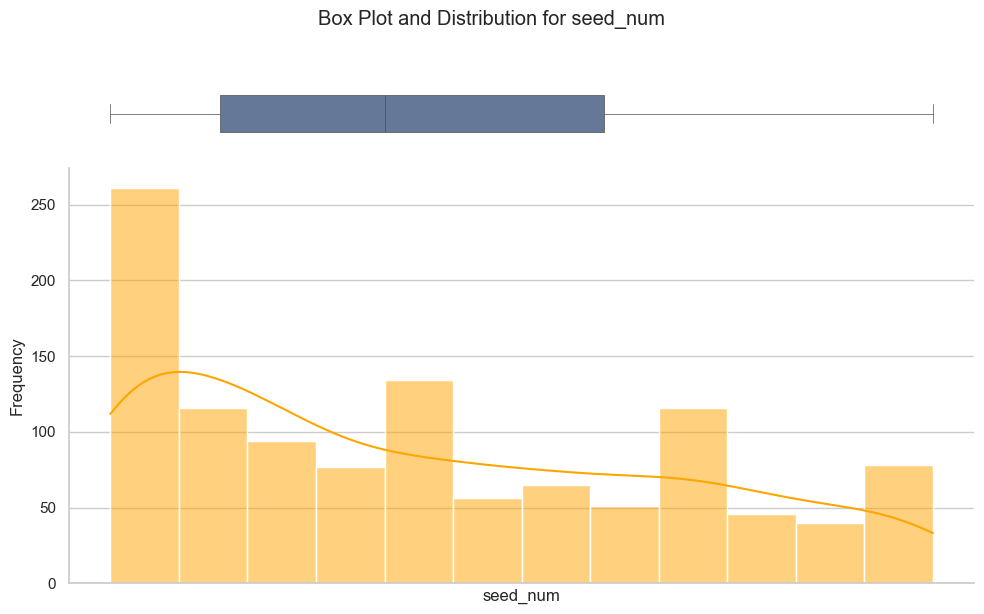

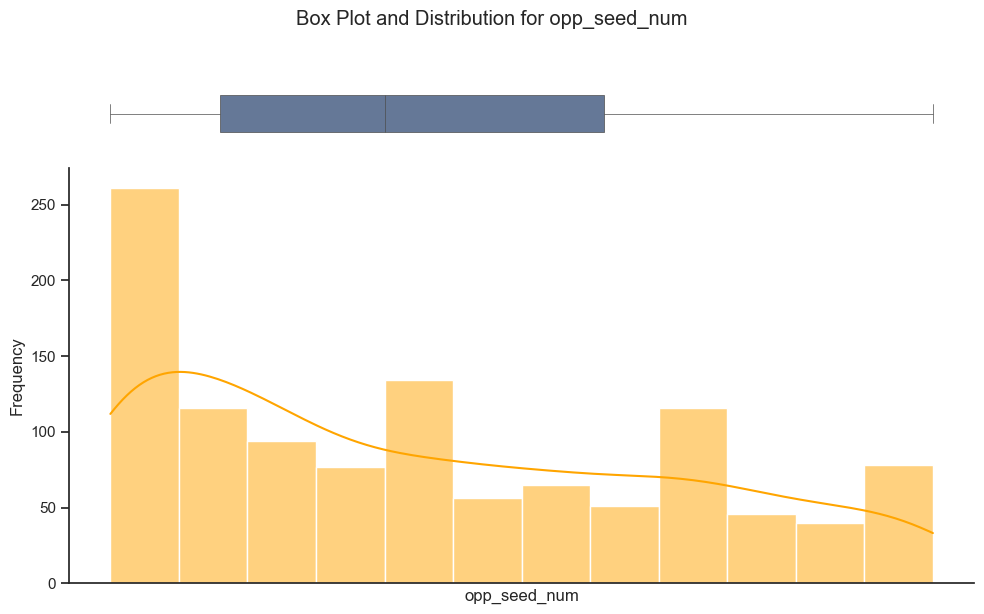

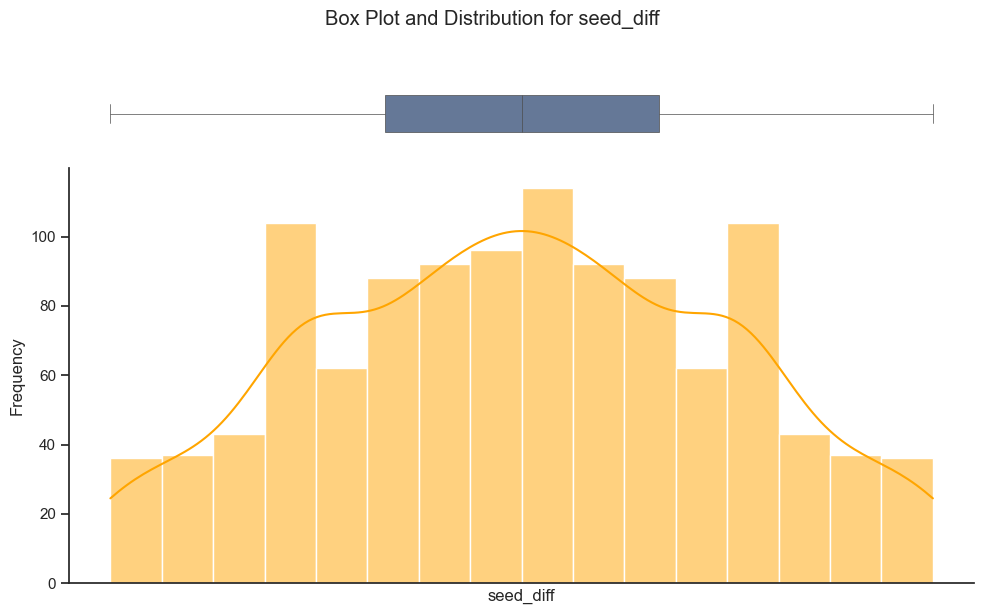

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
seed_num,int64,1134,0,16,1,1,3.0,6.0,10.0,16,6.698413,4.55668,0.457632,-1.006129
opp_seed_num,int64,1134,0,16,1,1,3.0,6.0,10.0,16,6.698413,4.55668,0.457632,-1.006129
seed_diff,int64,1134,0,29,-1,-15,-5.0,0.0,5.0,15,0.0,7.589187,0.0,-0.752326


In [60]:
safe_candidate_features = select_candidate_features(
    df=paired_games,
    blocked_columns=leakage_cols,
    baseline_features=BASELINE_FEATURES,
)
ranked_feature_pool, feature_ranking = rank_candidate_features(
    X_train=X_train,
    y_train=y_train,
    candidate_features=safe_candidate_features,
    baseline_features=BASELINE_FEATURES,
    max_features=24,
)

print(f"Baseline feature count: {len(BASELINE_FEATURES)}")
print(f"Safe numeric candidate count before ranking cap: {len(safe_candidate_features)}")
print(f"Ranked feature pool count used for backward elimination: {len(ranked_feature_pool)}")
print("Ranked feature pool:")
display(pd.DataFrame({"feature": ranked_feature_pool}))

print("Top training-ranked candidate features:")
display(feature_ranking.head(30))

if sns is not None:
    display(ml.univariate(X_train[BASELINE_FEATURES]))
else:
    print("seaborn is unavailable; showing pandas summary for baseline features instead.")
    display(X_train[BASELINE_FEATURES].describe().T)


In [61]:
selector_estimator = LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE)
selected_features, elimination_history, cv_name = run_backward_elimination(
    feature_cols=ranked_feature_pool,
    estimator=selector_estimator,
    X_train=X_train,
    y_train=y_train,
    groups_train=groups_train,
    tolerance=0.001,
    min_features=max(3, len(BASELINE_FEATURES)),
    scale_numeric=True,
)

print(f"Backward elimination CV strategy: {cv_name}")
print(f"Selected feature count: {len(selected_features)}")
print("Selected features:")
display(pd.DataFrame({"feature": selected_features}))

print("Backward elimination history:")
display(elimination_history.round({
    "cv_accuracy_mean": 3,
    "cv_accuracy_std": 3,
}))


Backward elimination CV strategy: GroupKFold(5) by year
Selected feature count: 14
Selected features:


,feature
0,seed_diff
1,diff_btp_weighted_bpm
2,diff_btp_weighted_gbpm
3,diff_btp_top_3_bpm_sum
4,diff_kp_badj_em
5,diff_kp_kadj_em
6,diff_bt_bt_em
7,diff_rppf_radj_em
8,diff_em_relative_rating
9,diff_bt_qual_barthag


Backward elimination history:


,step,removed_feature,remaining_feature_count,cv_accuracy_mean,cv_accuracy_std,accepted
0,0,<none>,24,0.760,0.022,True
1,1,diff_res_q1_plus_q2_w,23,0.767,0.023,True
2,2,diff_kp_barthag,22,0.773,0.035,True
3,3,diff_bt_qual_games,21,0.779,0.022,True
4,4,diff_kp_wab,20,0.786,0.009,True
5,5,diff_btp_weighted_obpm,19,0.794,0.031,True
6,6,diff_tr_tr_rating,18,0.795,0.028,True
7,7,barttorvik_team_strength_edge,17,0.795,0.028,True
8,8,diff_bt_qual_o,16,0.795,0.028,True
9,9,opp_seed_num,15,0.795,0.028,True


In [62]:
comparison_rows = []
fitted_validation_models: dict[str, Pipeline] = {}

evaluation_sets = {
    "baseline_seed_features": BASELINE_FEATURES,
    "full_ranked_pool": ranked_feature_pool,
    "backward_eliminated": selected_features,
}

for label, feature_cols in evaluation_sets.items():
    summary, pipeline = evaluate_feature_set(
        label=label,
        feature_cols=feature_cols,
        estimator=LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
        X_train=X_train,
        y_train=y_train,
        X_eval=X_val,
        y_eval=y_val,
        groups_train=groups_train,
        scale_numeric=True,
    )
    comparison_rows.append(summary)
    fitted_validation_models[label] = pipeline

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["validation_accuracy", "train_cv_accuracy_mean", "feature_count", "label"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

print("Validation comparison:")
display(comparison_df.round({
    "train_cv_accuracy_mean": 3,
    "train_cv_accuracy_std": 3,
    "validation_accuracy": 3,
}))

best_label = str(comparison_df["label"].iat[0])
final_feature_set = evaluation_sets[best_label]
print(f"Locked final feature set from validation: {best_label}")


Validation comparison:


,label,feature_count,cv_strategy,train_cv_accuracy_mean,train_cv_accuracy_std,validation_accuracy
0,backward_eliminated,14,GroupKFold(5) by year,0.795,0.028,0.746
1,full_ranked_pool,24,GroupKFold(5) by year,0.760,0.022,0.738
2,baseline_seed_features,3,GroupKFold(5) by year,0.727,0.028,0.700


Locked final feature set from validation: backward_eliminated


Final test accuracy: 0.721


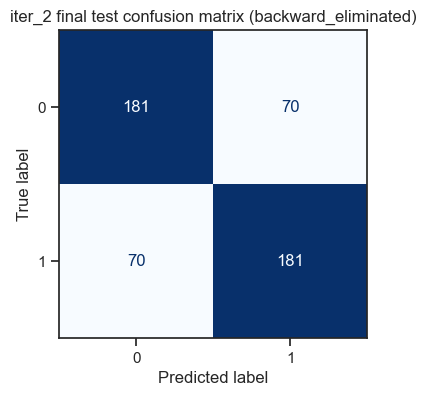

              precision    recall  f1-score   support

           0      0.721     0.721     0.721       251
           1      0.721     0.721     0.721       251

    accuracy                          0.721       502
   macro avg      0.721     0.721     0.721       502
weighted avg      0.721     0.721     0.721       502

Sample test errors:


,year,game_id,team,opp_team,seed_num,opp_seed_num,seed_diff,actual,predicted,pred_win
205,2012,2012_64_8,LIU Brooklyn,Michigan St.,16,1,15,0,1,0.998870
251,2012,2012_64_31,Detroit,Kansas,15,2,13,0,1,0.997481
77,2011,2011_64_7,LIU Brooklyn,North Carolina,15,2,13,0,1,0.979814
490,2022,2022_64_26,Iowa,Richmond,5,12,-7,0,1,0.969597
218,2012,2012_64_15,Missouri,Norfolk St.,2,15,-13,0,1,0.968997
100,2011,2011_64_19,Louisville,Morehead St.,4,13,-9,0,1,0.966080
18,2011,2011_16_2,Duke,Arizona,1,5,-4,0,1,0.914543
10,2011,2011_8_2,Kansas,VCU,1,11,-10,0,1,0.906929
304,2021,2021_32_11,Florida,Oral Roberts,7,15,-8,0,1,0.904478
271,2021,2021_16_2,Florida St.,Michigan,4,1,3,0,1,0.889826


In [63]:
final_model = make_pipeline(
    feature_cols=final_feature_set,
    estimator=LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    scale_numeric=True,
)
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)
print(f"Final test accuracy: {test_accuracy:.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"iter_2 final test confusion matrix ({best_label})")
plt.show()

print(classification_report(y_test, test_pred, digits=3))

test_view = paired_games.iloc[test_idx].copy().reset_index(drop=True)
test_view["actual"] = y_test.reset_index(drop=True)
test_view["predicted"] = pd.Series(test_pred)
if hasattr(final_model, "predict_proba"):
    test_view["pred_win"] = final_model.predict_proba(X_test)[:, 1]

error_cols = [
    column
    for column in [
        "year",
        "current_round",
        "game_id",
        "team",
        "opp_team",
        "seed_num",
        "opp_seed_num",
        "seed_diff",
        "actual",
        "predicted",
        "pred_win",
    ]
    if column in test_view.columns
]

print("Sample test errors:")
display(
    test_view.loc[test_view["actual"] != test_view["predicted"], error_cols]
    .sort_values("pred_win", ascending=False, na_position="last")
    .head(25)
)


In [64]:
development_idx = np.sort(np.concatenate([train_idx, val_idx]))
X_development = X.iloc[development_idx].copy()
y_development = y.iloc[development_idx].copy()

development_model = make_pipeline(
    feature_cols=final_feature_set,
    estimator=LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
    scale_numeric=True,
)
development_model.fit(X_development, y_development)

development_summary = pd.DataFrame(
    [
        {
            "dataset": "development_train_plus_validation",
            "rows": len(X_development),
            "share_of_full_data": len(X_development) / len(X),
            "feature_set": best_label,
            "feature_count": len(final_feature_set),
        },
        {
            "dataset": "held_out_test",
            "rows": len(X_test),
            "share_of_full_data": len(X_test) / len(X),
            "feature_set": best_label,
            "feature_count": len(final_feature_set),
        },
    ]
)

print("Development refit summary:")
display(development_summary)

iteration_summary = pd.DataFrame(
    [
        {
            "Iteration": "iter_2",
            "What Changed": "Used a deterministic 60/20/20 split, training-only backward elimination, and a locked final test audit.",
            "Selected Feature Set": best_label,
            "Selected Feature Count": len(final_feature_set),
            "Validation Score": comparison_df.loc[0, "validation_accuracy"],
            "Test Score": test_accuracy,
            "Keep / Drop Next Time": "Keep the three-way split and selection workflow; next compare the reduced subset against tree ensembles.",
        }
    ]
)

display(iteration_summary.round({
    "Validation Score": 3,
    "Test Score": 3,
}))


Development refit summary:


,dataset,rows,share_of_full_data,feature_set,feature_count
0,development_train_plus_validation,1638,0.765421,backward_eliminated,14
1,held_out_test,502,0.234579,backward_eliminated,14


,Iteration,What Changed,Selected Feature Set,Selected Feature Count,Validation Score,Test Score,Keep / Drop Next Time
0,iter_2,"Used a deterministic 60/20/20 split, training-...",backward_eliminated,14,0.746,0.721,Keep the three-way split and selection workflo...
